## OKOMUOIL STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

okomuoil=pd.read_csv('../stock_data/okomuoil.csv') ## so it can be small letter. This is cool.
okomuoil=okomuoil.drop(columns=['high_price','low_price'])
okomuoil.rename(columns={'trade_date':'date'},inplace=True)
okomuoil['date']=pd.to_datetime(okomuoil['date'])
okomuoil['month']=okomuoil['date'].dt.month
okomuoil['quarter']=okomuoil['date'].dt.quarter
okomuoil['year']=okomuoil['date'].dt.year

okomuoil

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42780,OKOMUOIL,2017-01-03,40.17,40.17,11642,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43340,OKOMUOIL,2017-01-04,40.17,40.17,247329,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43450,OKOMUOIL,2017-01-05,40.17,40.17,51330,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43560,OKOMUOIL,2017-01-06,40.17,40.17,46256,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43650,OKOMUOIL,2017-01-09,40.17,40.17,96200,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298114,OKOMUOIL,2026-07-13,1418.00,1418.00,72014,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298552,OKOMUOIL,2026-07-14,1418.00,1418.00,211490,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298990,OKOMUOIL,2026-07-15,1418.00,1418.00,54495,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299428,OKOMUOIL,2026-07-16,1418.00,1418.00,58435,2026-07-16T15:10:03.113936+00:00,7,3,2026


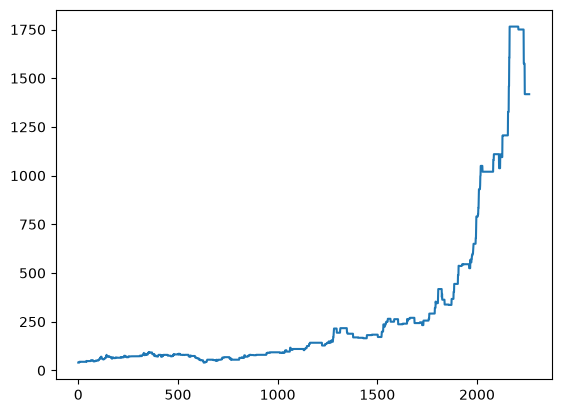

In [2]:
import matplotlib.pyplot as plt

plt.plot(okomuoil['close_price'])
plt.show()

In [3]:
okomuoil_end_month_df = (
    okomuoil
    .sort_values("date")
    .groupby(okomuoil["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

okomuoil_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45350,OKOMUOIL,2017-01-31,44.18,44.18,49500,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47171,OKOMUOIL,2017-02-28,46.38,46.38,239940,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49287,OKOMUOIL,2017-03-31,50.00,50.00,245440,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51115,OKOMUOIL,2017-04-28,47.05,47.05,154400,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53037,OKOMUOIL,2017-05-31,52.50,52.50,84754,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35351,OKOMUOIL,2026-03-31,1765.00,1765.00,71884,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281177,OKOMUOIL,2026-04-30,1750.00,1750.00,353836,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284243,OKOMUOIL,2026-05-29,1750.00,1750.00,67698,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294171,OKOMUOIL,2026-06-30,1418.00,1418.00,245117,2026-06-30T15:10:03.08168+00:00,6,2,2026


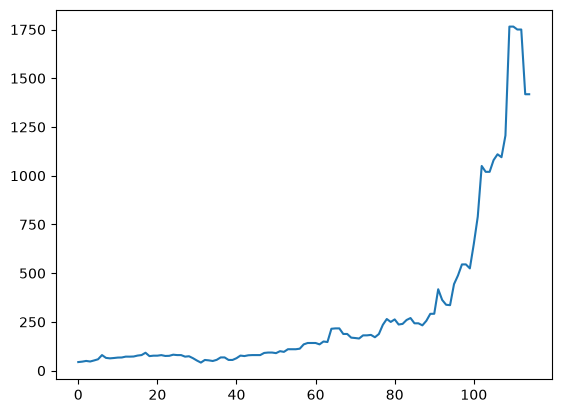

In [4]:
plt.plot(okomuoil_end_month_df['close_price'])
plt.show()

In [5]:
okomuoil_end_month_df['returns']=okomuoil_end_month_df['close_price'].pct_change()*100
okomuoil_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45350,OKOMUOIL,2017-01-31,44.18,44.18,49500,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47171,OKOMUOIL,2017-02-28,46.38,46.38,239940,2026-04-08T02:44:45.006295+00:00,2,1,2017,4.979629
2,49287,OKOMUOIL,2017-03-31,50.00,50.00,245440,2026-04-08T02:45:42.281198+00:00,3,1,2017,7.805088
3,51115,OKOMUOIL,2017-04-28,47.05,47.05,154400,2026-04-08T02:51:55.619599+00:00,4,2,2017,-5.900000
4,53037,OKOMUOIL,2017-05-31,52.50,52.50,84754,2026-04-08T02:52:57.421655+00:00,5,2,2017,11.583422
...,...,...,...,...,...,...,...,...,...,...,...
110,35351,OKOMUOIL,2026-03-31,1765.00,1765.00,71884,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.000000
111,281177,OKOMUOIL,2026-04-30,1750.00,1750.00,353836,2026-04-30T15:00:02.170664+00:00,4,2,2026,-0.849858
112,284243,OKOMUOIL,2026-05-29,1750.00,1750.00,67698,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.000000
113,294171,OKOMUOIL,2026-06-30,1418.00,1418.00,245117,2026-06-30T15:10:03.08168+00:00,6,2,2026,-18.971429


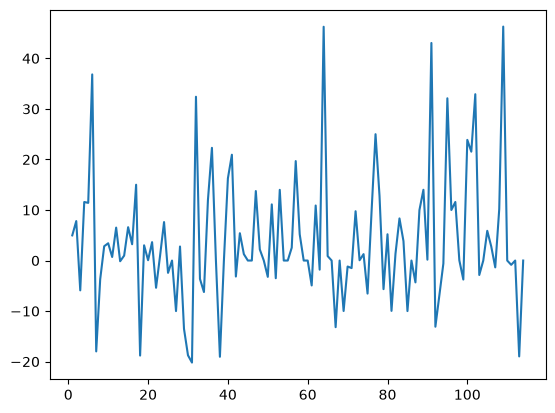

In [6]:
plt.plot(okomuoil_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(okomuoil_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-7.583092047435527), np.float64(2.649931969431588e-11), 2, 111, {'1%': np.float64(-3.490683082754047), '5%': np.float64(-2.8879516565798817), '10%': np.float64(-2.5808574442009578)}, np.float64(798.5641970585065))
stationary


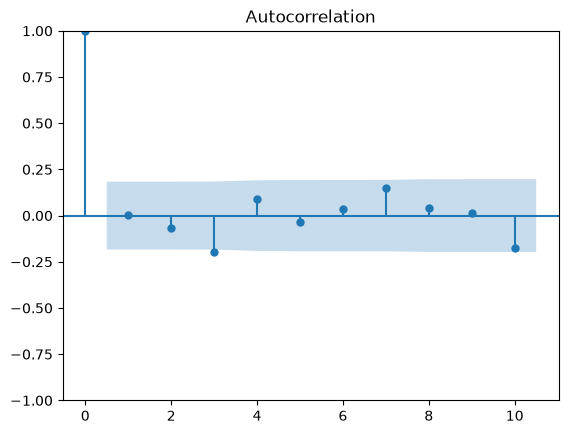

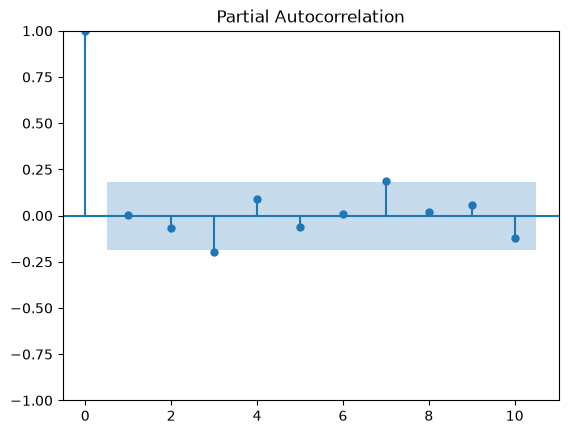

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(okomuoil_end_month_df['returns'].dropna(), lags=10)
plot_pacf(okomuoil_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=okomuoil_end_month_df['close_price'][:-10]
test=okomuoil_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -25.253177621714975]
[0, 0, 0, 0, 0, 1, -13.637593975613523]
[0, 0, 0, 0, 0, 2, -8.414385551310874]
[0, 0, 0, 0, 1, 0, -9.175722175338045]
[0, 0, 0, 0, 1, 1, -5.803829062344038]
[0, 0, 0, 0, 1, 2, -5.247001890067951]
[0, 0, 0, 0, 2, 0, -4.586093698628725]
[0, 0, 0, 0, 2, 1, -4.112625128253635]
[0, 0, 0, 0, 2, 2, -4.198478956271088]
[0, 0, 0, 1, 0, 0, -10.080341653498042]
[0, 0, 0, 1, 0, 1, -6.435249030917532]
[0, 0, 0, 1, 0, 2, -6.510132563454672]
[0, 0, 0, 1, 1, 0, -5.681455948118766]
[0, 0, 0, 1, 1, 1, -4.913380761934478]
[0, 0, 0, 1, 1, 2, -5.048091849700405]
[0, 0, 0, 1, 2, 0, -4.2518605070280255]
[0, 0, 0, 1, 2, 1, -4.438515805980474]
[0, 0, 0, 1, 2, 2, -4.1135782357810875]
[0, 0, 0, 2, 0, 0, -7.35522537580688]
[0, 0, 0, 2, 0, 1, -6.216024366965428]
[0, 0, 0, 2, 0, 2, -6.381203455202916]
[0, 0, 0, 2, 1, 0, -5.612300708719134]
[0, 0, 0, 2, 1, 1, -4.996305673877119]
[0, 0, 0, 2, 1, 2, -5.168451341202366]
[0, 0, 0, 2, 2, 0, -4.374824468079161]
[0, 0, 0, 2, 2, 1, -4

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
536,2,0,1,2,2,1,-148832.757073
616,2,1,1,2,2,0,-2620.013518
0,0,0,0,0,0,0,-25.253178
27,0,0,1,0,0,0,-24.111411
54,0,0,2,0,0,0,-23.670047
...,...,...,...,...,...,...,...
673,2,2,1,0,0,0,0.131908
208,0,2,1,2,0,2,0.132271
197,0,2,1,1,0,0,0.132806
189,0,2,1,0,0,1,0.133236


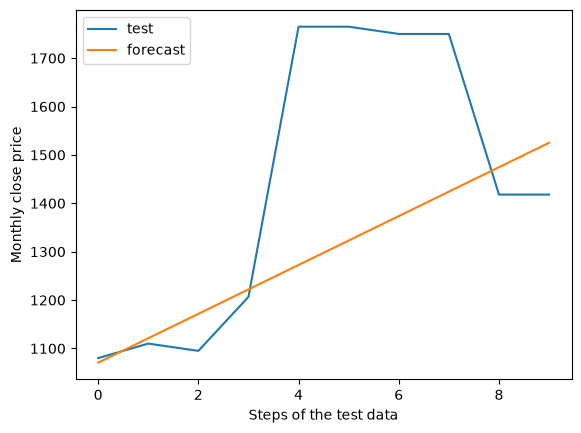

r2_score:  0.1340589059665851
rmse:  265.86733556703723
description:  count     115.000000
mean      296.285565
std       410.884744
min        41.500000
25%        74.825000
50%       135.000000
75%       261.500000
max      1765.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=okomuoil_end_month_df['close_price'][:-10]
y_test=okomuoil_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,1), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', okomuoil_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=okomuoil_end_month_df['returns'].dropna()[:-10]
test=okomuoil_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.07862196838479463]
[0, 0, 0, 0, 0, 1, -0.0740337812112617]
[0, 0, 0, 0, 0, 2, -0.1303789471103569]
[0, 0, 0, 0, 1, 0, -1.3596471819382479]
[0, 0, 0, 0, 1, 1, -0.4128041030147489]
[0, 0, 0, 0, 1, 2, -0.5137567228043025]
[0, 0, 0, 0, 2, 0, -3.7415973641161067]
[0, 0, 0, 0, 2, 1, -1.5438037161538034]
[0, 0, 0, 0, 2, 2, -1.3837729618596404]
[0, 0, 0, 1, 0, 0, -0.07804444625339646]
[0, 0, 0, 1, 0, 1, -0.23329172997204917]
[0, 0, 0, 1, 0, 2, -0.2739455118333245]
[0, 0, 0, 1, 1, 0, -0.8957988219298949]
[0, 0, 0, 1, 1, 1, -0.47310405025579505]
[0, 0, 0, 1, 1, 2, -0.458170086352534]
[0, 0, 0, 1, 2, 0, -1.8885996965107763]
[0, 0, 0, 1, 2, 1, -1.146341974582045]
[0, 0, 0, 1, 2, 2, -1.3785276432306297]
[0, 0, 0, 2, 0, 0, -0.15998839532283715]
[0, 0, 0, 2, 0, 1, -0.25236538349958426]
[0, 0, 0, 2, 0, 2, -0.2738335817361057]
[0, 0, 0, 2, 1, 0, -0.8281677665472771]
[0, 0, 0, 2, 1, 1, -0.5978674456158688]
[0, 0, 0, 2, 1, 2, -0.6328851246185063]
[0, 0, 0, 2, 2, 0, -1.99924579205826

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
167,0,2,0,0,2,0,-2828.501073
176,0,2,0,1,2,0,-1201.070681
168,0,2,0,0,2,1,-841.977247
164,0,2,0,0,1,0,-619.708732
185,0,2,0,2,2,0,-397.839309
...,...,...,...,...,...,...,...
108,0,1,1,0,0,1,-0.007438
134,0,1,2,0,0,0,-0.003969
278,1,0,1,1,0,0,-0.003837
350,1,1,1,0,0,0,-0.003747


Very horrible. We will work with close_price
